In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Read data
normal = pd.read_csv('2025_arrival_records_merge_normal.csv', low_memory=False)
grandprix = pd.read_csv('2025_arrival_records_merge_grandprix.csv', low_memory=False)

In [3]:
# Extract hour information from the time column
normal['hour'] = pd.to_datetime(normal['time'], format='%H:%M:%S').dt.hour
grandprix['hour'] = pd.to_datetime(grandprix['time'], format='%H:%M:%S').dt.hour

In [4]:
# Select features and create subsets
features = ['route', 'hour', 'weekday', 'passengerFlow', 'trafficCondition', 'weather', 'arrivalDuration']
normal_features = normal[features].copy()
grandprix_features = grandprix[features].copy()

In [5]:
# Processing the 'route' column: Convert to numeric or factorized encoding
print("Processing the 'route' column of the Normal dataset...")
if normal_features['route'].dtype == 'object':
    normal_features['route'] = pd.factorize(normal_features['route'])[0]
    print("Normal: 'route' column has been factorized.")
else:
    normal_features['route'] = pd.to_numeric(normal_features['route'], errors='coerce')
    print("Normal: 'route' column has been converted to numeric type.")

print("\nProcessing the 'route' column of the Grandprix dataset...")
if grandprix_features['route'].dtype == 'object':
    grandprix_features['route'] = pd.factorize(grandprix_features['route'])[0]
    print("Grandprix: 'route' column has been factorized.")
else:
    grandprix_features['route'] = pd.to_numeric(grandprix_features['route'], errors='coerce')
    print("Grandprix: 'route' column has been converted to numeric type.")

Processing the 'route' column of the Normal dataset...
Normal: 'route' column has been factorized.

Processing the 'route' column of the Grandprix dataset...
Grandprix: 'route' column has been factorized.


In [6]:
# Selecting features for correlation analysis
features_for_corr = ['route', 'hour', 'weekday', 'passengerFlow', 'trafficCondition', 'weather', 'arrivalDuration']

In [7]:
# Data cleaning (dropping NaN values)
normal_clean = normal_features[features_for_corr].dropna()
grandprix_clean = grandprix_features[features_for_corr].dropna()

In [8]:
# Calculating the correlation coefficient matrix
corr_normal = normal_clean.corr()
corr_grandprix = grandprix_clean.corr()

In [9]:
# Create a mask to hide the upper triangular part
mask_normal = np.triu(np.ones_like(corr_normal, dtype=bool))
mask_grandprix = np.triu(np.ones_like(corr_grandprix, dtype=bool))

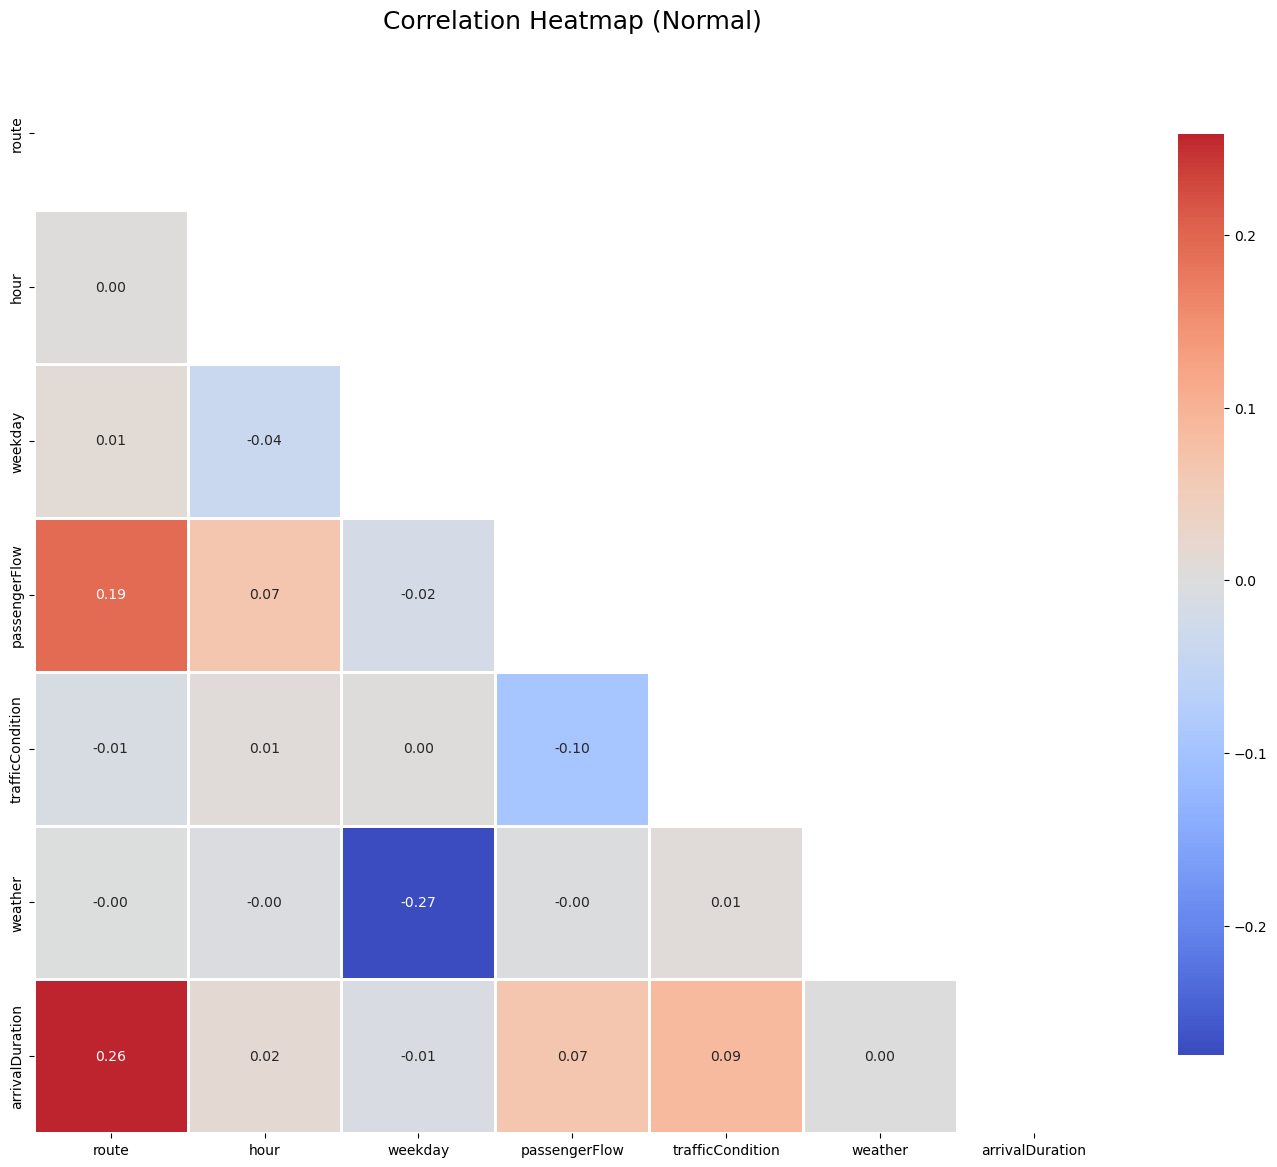

In [10]:
# Create heatmap for normal data
plt.figure(figsize=(14, 12))
sns.heatmap(corr_normal, mask=mask_normal, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap (Normal)', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

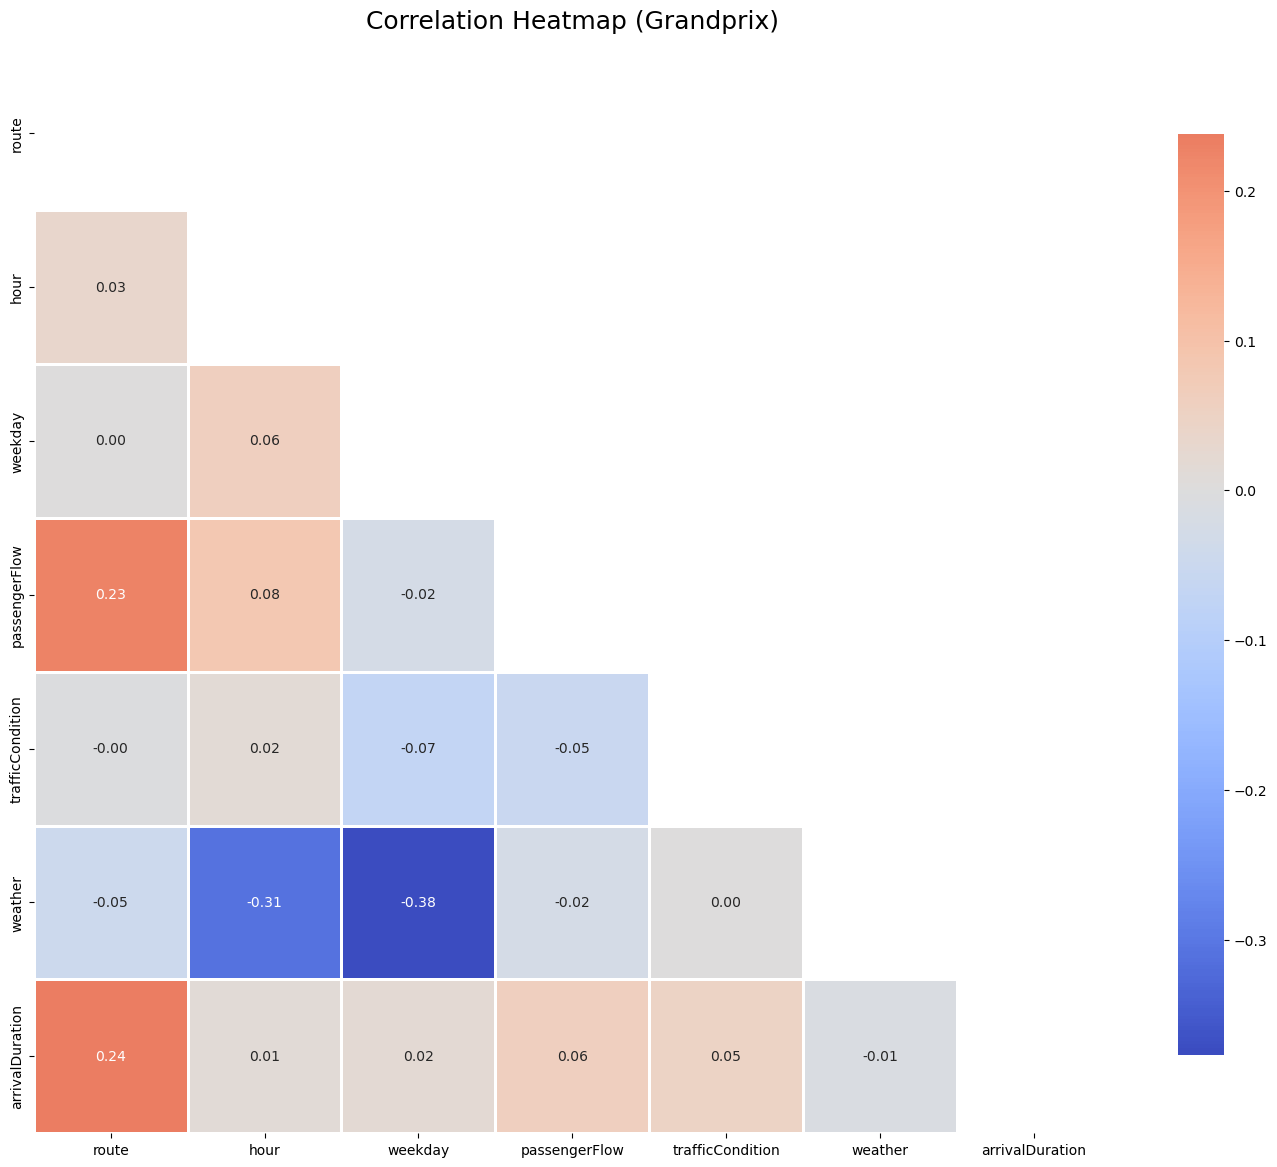

In [11]:
# Create heatmap for grandprix data
plt.figure(figsize=(14, 12))
sns.heatmap(corr_grandprix, mask=mask_grandprix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap (Grandprix)', fontsize=18, pad=20)
plt.tight_layout()
plt.show()